# ClaimStruct CX Classifier

## Multi-Task Transformer for Intent Classification and NER
Portfolio Project | Deep Learning and NLP


## Project Overview
This notebook implements and evaluates a multi-task Transformer pipeline for Spanish banking-claim conversations.

### Problem Definition
Manual triage of customer claims is slow and inconsistent at scale. The system developed here performs:
1. conversation-level intent classification, and
2. token-level entity extraction (NER).

The objective is to produce structured, operationally useful outputs that improve downstream routing and analytics. This is an internal decision-support model, not a generative assistant.


## Implementation: Imports and Dependencies


If dependency resolution fails in a fresh runtime, uncomment the compatibility commands below.


In [1]:
# !pip uninstall -y transformers
# !pip install transformers==4.41.2

In [2]:
from __future__ import annotations

import json
import os
import random
import re
import textwrap
import warnings
import zipfile
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from scipy import stats
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
from huggingface_hub import snapshot_download
from keras_hub.models import BertBackbone
from safetensors import safe_open
from safetensors.torch import save_file
from transformers import AutoTokenizer

/Users/jnahui/Desktop/Proyects.nosync/Jeasmine.github.io/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Fuerza a que las operaciones internas de TensorFlow produzcan resultados reproducibles
tf.config.experimental.enable_op_determinism()

In [4]:
warnings.filterwarnings("ignore")
# Controla el nivel de logs de TensorFlow. 2 oculta INFO y WARNING
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

## Methodology: Configuration and Reproducibility
Configuration centralizes seeds, visualization options, model hyperparameters, and training controls to ensure deterministic and repeatable experiments.


In [5]:
@dataclass
class Config:
    # --- Configuracion de visualizacion ---
    palette: list = field(default_factory=lambda: [
        '#a5c4beff',  # verde salvia suave
        '#ffc0c0ff',  # rosa pastel
        '#3f5a6bff',  # azul petróleo
        '#f38681ff',  # coral suave
        '#00c3b1ff',  # turquesa vibrante
        '#6c8ea3ff',  # azul grisáceo medio
        '#b8a1c9ff',  # lavanda apagada
        '#f2b880ff',  # durazno cálido
        '#7bbfa5ff',  # verde menta medio
        '#d97d54ff',  # terracota suave
    ])
    bg_color: str = "#f7ecdcff" # Color de fondo de las figuras
    fig_w: int = 10             # Ancho de las figuras en pulgadas
    fig_h: int = 4              # Alto de las figuras en pulgadas
    dpi: int = 130              # Resolucion de las figuras
    sample_pairplot: int = 2000 # Cantidad de muestras para el pairplot (evita graficos lentos)
    seed: int = 42              # Semilla para reproducibilidad

    # --- Configuracion del modelo BERT ---
    bert_model_name: str = "dccuchile/bert-base-spanish-wwm-cased"  # Modelo preentrenado en español
    # 256 tokens para acomodar conversaciones completas (mas largas que un solo mensaje)
    max_length: int = 256

    # --- Configuracion del entrenamiento ---
    batch_size: int = 16              # Cantidad de muestras por batch
    epochs: int = 10                  # Numero maximo de epocas de entrenamiento
    learning_rate: float = 3e-5       # Tasa de aprendizaje (valor tipico para fine-tuning de BERT)
    early_stopping_patience: int = 3  # Epocas sin mejora antes de detener el entrenamiento
    intent_loss_weight: float = 1.0   # Peso de la loss de clasificacion de intents
    ner_loss_weight: float = 1.0      # Peso de la loss de NER (balance entre ambas tareas)
    dropout_rate: float = 0.3         # Tasa de dropout para regularizacion del modelo (0.0 = sin dropout, 1.0 = todo apagado)

    # --- Configuracion general ---
    seed: int = 42                # Semilla para reproducibilidad
    ner_ignore_index: int = -100  # Valor que indica tokens a ignorar en el calculo de la loss NER

    # --- Configuracion del preprocesamiento de texto ---
    # Separador entre mensajes dentro de una conversacion
    msg_separator: str = " [SEP] "
    # Prefijos para identificar al hablante en el texto concatenado (ej: "[AGENT] ", "[CLIENT] ")
    speaker_prefix: bool = True

# Instanciar configuracion global
cfg = Config()

In [6]:
sns.set_theme(
    style="white",
    rc={
        "figure.facecolor": cfg.bg_color,
        "axes.facecolor": cfg.bg_color
    }
)

In [7]:
def set_global_seed(seed):

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Fuerza operaciones deterministas en GPU (muy importante)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [8]:
set_global_seed(cfg.seed)

## Implementation: Utility Functions


In [9]:
def anonimizar_texto(texto: str) -> str:
    """
    Reemplaza menciones al banco por un token anonimo.
    Cubre variantes: itau, Itau, itaú, Itaú, ITAU, banco itau,
    Itaú: (seguido de dos puntos) etc.
    """
    patrones = [
        r"[Bb]anco\s+[Ii]ta[uú][eé]?s?\s*:?",   # banco itau, Banco Itaú:
        r"[Ii]ta[uú]\s+[Bb]anco\s*:?",            # itau banco:
        r"[Ii]ta[uú][eé]?s?\s*:?",                # itau, Itaú, itaues, Itaú:
        r"ITAU[EÉ]?S?\s*:?",                       # ITAU, ITAUES, ITAU:
    ]

    patron_combinado = "|".join(patrones)

    return re.sub(patron_combinado, "[BANCO]", texto)

### Data Helpers
These helpers handle extraction, joins, integrity checks, and safe aggregations used across data preparation and evaluation steps.


In [10]:
def extract_zip(zip_path: str, extract_dir: str) -> None:
    """
    Extract a zip into `extract_dir`, resolving paths from the current notebook
    working directory.

    If `zip_path` is empty, it defaults to `<extract_dir>.zip`.
    """
    cwd = os.getcwd()

    zip_name = zip_path.strip() if zip_path and zip_path.strip() else f"{extract_dir}.zip"
    zip_file = zip_name if os.path.isabs(zip_name) else os.path.join(cwd, zip_name)

    extract_target = extract_dir if os.path.isabs(extract_dir) else os.path.join(cwd, extract_dir)

    if not os.path.exists(zip_file):
        raise FileNotFoundError(f"Zip file not found: {zip_file}")

    os.makedirs(extract_target, exist_ok=True)
    with zipfile.ZipFile(zip_file, "r") as z:
        z.extractall(extract_target)

    print(f"Extracted: {zip_file} -> {extract_target}")


def safe_read_csv(path: str) -> pd.DataFrame:
    return pd.read_csv(path)

In [11]:
def mostrar_conversaciones_random(df, n_conversations=3):
    conv_ids = df["conversation_id"].dropna().unique()

    selected_convs = random.sample(
        list(conv_ids),
        min(n_conversations, len(conv_ids))
    )

    for cid in selected_convs:
        df_conv = df[df["conversation_id"] == cid] \
            .sort_values("timestamp_offset_sec")

        # Tomar reason_code_primary (puede repetirse dentro de la conv)
        reason = df_conv["reason_code_primary"].dropna().iloc[0] \
            if "reason_code_primary" in df_conv.columns else "UNKNOWN"

        print("\n" + "="*80)
        print(f"CONVERSATION ID: {cid}")
        print(f"REASON CODE: {reason}")
        print("="*80)

        for _, row in df_conv.iterrows():

            print(f"[{row['speaker'].upper()}] {row['text']}")
            print()

        print("="*80 + "\n")

In [12]:
def check_col(df: pd.DataFrame, col: str) -> bool:
    """Verifica que la columna exista y tenga datos no nulos."""
    return col in df.columns and df[col].notna().any()

In [13]:
def crosstab_safe(df: pd.DataFrame,
                  row: str,
                  col: str) -> Optional[pd.DataFrame]:
    """Crosstab solo si ambas columnas tienen datos."""
    if check_col(df, row) and check_col(df, col):
        return pd.crosstab(df[row], df[col])
    return None

In [14]:
def agregar_por_conversacion(messages: pd.DataFrame, entities: pd.DataFrame) -> pd.DataFrame:
    """Calcula metricas agregadas por conversacion: mensajes, palabras, duracion, entidades."""
    # Agrupa los mensajes por conversacion y calcula metricas de texto y duracion
    msg_agg = messages.groupby("conversation_id").agg(
        # Cantidad total de mensajes en la conversacion
        n_msgs=("message_id", "size"),
        # Total de palabras sumando las palabras de cada mensaje
        total_words=("text", lambda x: x.astype(str).str.split().str.len().sum()),
        # Total de caracteres sumando la longitud de cada mensaje
        total_chars=("text", lambda x: x.astype(str).str.len().sum()),
        # Duracion en segundos
        duracion_sec=("timestamp_offset_sec", lambda x: x.max() - x.min()),
    ).reset_index()

    # Agrupa las entidades por conversacion y calcula metricas de entidades
    ent_agg = entities.groupby("conversation_id").agg(
        # Cantidad total de entidades detectadas en la conversacion
        n_entities=("entity_type", "size"),
        # Cantidad de tipos de entidades distintos (ej: PERSON, ORG, DATE...)
        n_entity_types=("entity_type", "nunique"),
    ).reset_index()

    # Une ambas tablas por conversation_id usando left join para conservar
    # todas las conversaciones, incluso las que no tienen entidades
    df = msg_agg.merge(ent_agg, on="conversation_id", how="left")

    # Las conversaciones sin entidades quedan con NaN tras el merge,
    # se reemplazan por 0
    df[["n_entities", "n_entity_types"]] = df[["n_entities", "n_entity_types"]].fillna(0).astype(int)

    return df

In [15]:
def encode_categoricals(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """Codifica columnas categoricas como enteros para calcular correlaciones."""
    out = df[cols].copy()
    for c in cols:
        out[c] = out[c].astype("category").cat.codes
    return out

In [16]:
def print_dataframe_info(name: str, df: pd.DataFrame) -> None:
    """
    Imprime información estructural básica de un DataFrame.
    """
    print("\n" + "=" * 60)
    print(f"{name.upper()}")
    print("=" * 60)

    print("\nShape:")
    print(df.shape)

    print("\nColumnas:")
    print(list(df.columns))

    print("\nTipos de datos:")
    print(df.dtypes)

    print("\nValores nulos por columna:")
    print(df.isnull().sum().sort_values(ascending=False))

    print("\nMemoria aproximada en MB:")
    print(round(df.memory_usage(deep=True).sum() / 1024**2, 3))

    print("\nEstadísticas descriptivas:")
    print(df.describe(include="all"))

In [17]:
def print_multiple_dataframes_info(dfs: dict) -> None:
    """
    Recibe un diccionario {nombre: dataframe} y muestra info para cada uno.
    """
    print("===== INFORMACIÓN GENERAL =====")
    for name, df in dfs.items():
        print_dataframe_info(name, df)

## Data Ingestion


In [18]:
extract_dir = "claimstruct_multitable_v2"
extract_zip("", extract_dir)

Extracted: /Users/jnahui/Desktop/Proyects.nosync/Jeasmine.github.io/cx_classifier/claimstruct_multitable_v2.zip -> /Users/jnahui/Desktop/Proyects.nosync/Jeasmine.github.io/cx_classifier/claimstruct_multitable_v2


In [19]:
conversations_path = os.path.join(extract_dir, "conversations.csv")
messages_path = os.path.join(extract_dir, "messages.csv")
labels_path = os.path.join(extract_dir, "labels.csv")
entities_path = os.path.join(extract_dir, "entities.csv")

conversations = safe_read_csv(conversations_path)
messages = safe_read_csv(messages_path)
labels = safe_read_csv(labels_path)
entities = safe_read_csv(entities_path)

In [20]:
print("Shapes:")
for n, df in [("messages", messages), ("labels", labels),
              ("entities", entities), ("conversations", conversations)]:
    print(f"  {n}: {df.shape}")

Shapes:
  messages: (46713, 5)
  labels: (8000, 13)
  entities: (16502, 9)
  conversations: (8000, 10)


## Data Description


### Data Quality and Integrity


The training corpus is composed of four linked tables (`conversations`, `messages`, `labels`, `entities`) at conversation and message granularity. Integrity checks confirm the data is suitable for supervised multi-task training, with missingness concentrated in optional label fields.


In [21]:
print_multiple_dataframes_info({
    "Conversations": conversations,
    "Messages": messages,
    "Labels": labels,
    "Entities": entities
})

===== INFORMACIÓN GENERAL =====

CONVERSATIONS

Shape:
(8000, 10)

Columnas:
['conversation_id', 'created_at', 'channel', 'language', 'customer_segment', 'country', 'product_hint', 'is_synthetic', 'dataset_version', 'split']

Tipos de datos:
conversation_id      str
created_at           str
channel              str
language             str
customer_segment     str
country              str
product_hint         str
is_synthetic        bool
dataset_version      str
split                str
dtype: object

Valores nulos por columna:
conversation_id     0
created_at          0
channel             0
language            0
customer_segment    0
country             0
product_hint        0
is_synthetic        0
dataset_version     0
split               0
dtype: int64

Memoria aproximada en MB:
4.07

Estadísticas descriptivas:
       conversation_id           created_at channel language customer_segment  \
count             8000                 8000    8000     8000             8000   
unique     

### Initial Exploration
This quick inspection validates schema, sample rows, and key joins before feature construction.


In [22]:
labels.head()

,conversation_id,intent_primary,intent_secondary,product_final,reason_code_primary,severity,fraud_risk,outcome,routing_queue,label_source,labeler_id,label_version,split
0,conv_001706,rechazo_prevencion_fraude,fraude_desconocimiento,tarjeta_debito,autorizacion_rechazada_prevencion_fraude,medium,medium,escalated,cards_ops,synthetic,generator,v1,train
1,conv_006186,acreditacion_transferencia,acreditacion_pago,transferencia,no_acredita_transferencia,low,low,resolved,accounts_ops,synthetic,generator,v1,train
2,conv_000900,rechazo_prevencion_fraude,NaN,tarjeta_debito,autorizacion_rechazada_prevencion_fraude,medium,medium,resolved,cards_ops,synthetic,generator,v1,train
3,conv_007454,acceso_canales_digitales,NaN,canales_digitales,problema_acceso_clave,low,low,resolved,digital_support,synthetic,generator,v1,train
4,conv_002773,controversia_compra,NaN,tarjeta_credito,controversia_compra,medium,low,escalated,cards_ops,synthetic,generator,v1,train


In [23]:
entities.head()

,conversation_id,message_id,entity_type,start_char,end_char,text_span,normalized_value,confidence,extractor_source
0,conv_000001,conv_000001_msg_002,amount,38,43,89.00,89.00,0.95,synthetic
1,conv_000001,conv_000001_msg_002,currency,44,47,EUR,EUR,0.91,synthetic
2,conv_000001,conv_000001_msg_004,country,22,36,Estados Unidos,ESTADOS UNIDOS,0.94,synthetic
3,conv_000002,conv_000002_msg_004,country,22,36,Estados Unidos,ESTADOS UNIDOS,0.88,synthetic
4,conv_000003,conv_000003_msg_002,amount,38,43,"59,99","59,99",0.96,synthetic


In [24]:
messages["text"] = messages["text"].astype(str).apply(anonimizar_texto)

In [25]:
conversations.head()

,conversation_id,created_at,channel,language,customer_segment,country,product_hint,is_synthetic,dataset_version,split
0,conv_000001,2025-03-18T11:24:00,callcenter,es,retail,Uruguay,tarjeta_debito,True,v2_realistic_multitable,train
1,conv_000002,2025-05-01T03:49:00,app,es,retail,Uruguay,tarjeta_credito,True,v2_realistic_multitable,train
2,conv_000003,2025-04-24T17:16:00,callcenter,es,retail,Uruguay,tarjeta_credito,True,v2_realistic_multitable,train
3,conv_000004,2025-02-17T08:07:00,chat,es,retail,Uruguay,tarjeta_debito,True,v2_realistic_multitable,train
4,conv_000005,2025-02-15T20:14:00,callcenter,es,retail,Uruguay,tarjeta_debito,True,v2_realistic_multitable,test


In [26]:
messages.head()

,conversation_id,message_id,speaker,timestamp_offset_sec,text
0,conv_000001,conv_000001_msg_001,customer,0,"Hola, buenas. Soy Valentina. Estoy intentando ..."
1,conv_000001,conv_000001_msg_002,customer,31,Me figura autorización rechazada por 89.00 EUR.
2,conv_000001,conv_000001_msg_003,agent,57,"Bien, reviso seguridad. ¿La compra es por inte..."
3,conv_000001,conv_000001_msg_004,customer,79,Es por internet desde Estados Unidos. En el su...
4,conv_000001,conv_000001_msg_005,agent,108,Soporte: Puede ser prevención de fraude. Podem...


In [27]:
messages_labels = pd.merge(
    messages,
    labels,
    on=["conversation_id", "conversation_id"],
    how="left"
)

In [28]:
# Este dataframe es la base de todo el analisis cruzado.
conv_stats = agregar_por_conversacion(messages, entities)
conv_stats = conv_stats.merge(
    labels[["conversation_id", "intent_primary"]],
    on="conversation_id", how="inner")

print(conv_stats.describe(include="all").round(1))

       conversation_id  n_msgs  total_words  total_chars  duracion_sec  \
count             8000  8000.0       8000.0       8000.0        8000.0   
unique            8000     NaN          NaN          NaN           NaN   
top        conv_000001     NaN          NaN          NaN           NaN   
freq                 1     NaN          NaN          NaN           NaN   
mean               NaN     5.8         52.8        325.5          94.4   
std                NaN     2.1         20.9        133.6          56.1   
min                NaN     3.0         15.0         87.0          16.0   
25%                NaN     3.0         30.0        171.0          49.8   
50%                NaN     6.0         58.0        350.0          84.0   
75%                NaN     6.0         62.0        391.0         123.0   
max                NaN    11.0        111.0        702.0         319.0   

        n_entities  n_entity_types             intent_primary  
count       8000.0          8000.0             

In [29]:
mostrar_conversaciones_random(
    messages_labels,
    n_conversations=3
)


CONVERSATION ID: conv_005239
REASON CODE: otros_reclamos_cuenta
[CUSTOMER] Buenas. Soy Lucía. Tengo una consulta sobre mi cuenta.

[CUSTOMER] me figura un débito automático que no reconozco en la cuenta.

[AGENT] Revisamos el detalle y te indico el procedimiento o sector.

[CUSTOMER] Lucía: Perfecto, quedo atento/a.

[AGENT] Asesor/a: Te dejo registrado el caso y próximos pasos.

[CUSTOMER] Lucía: Me pasó también ayer, por eso consulto.

[AGENT] Asesor/a: Entiendo. Te hago unas preguntas de validación y dejamos todo asentado.

[CUSTOMER] Lucía: Dale, decime.

[CUSTOMER] Listo, gracias.



CONVERSATION ID: conv_000913
REASON CODE: autorizacion_rechazada_prevencion_fraude
[CUSTOMER] Buenas. Soy Rodrigo. Estoy intentando pagar y me rechaza la tarjeta de crédito.

[CUSTOMER] Me figura autorización rechazada en Amazon .

[AGENT] Bien, reviso seguridad. ¿La compra es por internet o internacional?

[CUSTOMER] a ver Es por internet desde Brasil. En el super me dejó, acá no.

[AGENT] Atención 

## Methodology


The end-to-end pipeline follows seven stages:
1. Build conversation-level samples from message sequences and entity spans.
2. Create deterministic intent/BIO vocabularies.
3. Tokenize text and align character spans to token labels.
4. Create `tf.data` datasets for train/validation/test.
5. Build a shared-encoder multi-task BERT model.
6. Train with task-specific losses and stabilization callbacks.
7. Evaluate intent and NER with class-sensitive metrics.

Design choice: use a frozen encoder by default to improve stability on synthetic data and reduce overfitting risk.


## Implementation


`concatenar_conversacion` constructs a single conversation string in chronological order and remaps entity offsets from message-local to conversation-global coordinates. This guarantees that NER supervision remains consistent after concatenation.


In [30]:
def concatenar_conversacion(
    grupo_msgs,
    grupo_ents,
    cfg
):
    """
    Ordena mensajes cronológicamente, concatena el texto de la conversación
    y ajusta las posiciones de entidades a coordenadas globales.

    Versión robusta:
    - Limpia texto
    - Valida spans
    - Evita desalineación con separadores
    - Protege contra errores de dataset sintético
    """

    # Ordenar mensajes cronológicamente
    msgs = grupo_msgs.sort_values("timestamp_offset_sec")

    # Indexar entidades por message_id para lookup O(1)
    ents_by_msg = {}
    for mid, g in grupo_ents.groupby("message_id"):
        ents_by_msg[mid] = g

    partes = []
    spans = []

    offset_global = 0

    # Pre-calcular separador (evita recalcular length múltiples veces)
    sep = cfg.msg_separator
    sep_len = len(sep)

    for idx, row in enumerate(msgs.itertuples()):

        # --- Limpiar texto ---
        texto_msg = "" if pd.isna(row.text) else str(row.text)
        texto_msg = " ".join(texto_msg.split())  # elimina espacios y saltos de línea

        prefijo = ""
        if cfg.speaker_prefix:
            prefijo = f"[{str(row.speaker).upper()}] "

        fragmento = prefijo + texto_msg
        fragmento_len = len(fragmento)

        msg_id = row.message_id

        # --- Procesar entidades ---
        if msg_id in ents_by_msg:

            for _, ent in ents_by_msg[msg_id].iterrows():

                try:
                    local_start = int(ent["start_char"])
                    local_end = int(ent["end_char"])

                    # Validaciones básicas de coherencia
                    if local_start >= local_end:
                        continue

                    # Offset global + prefijo
                    span_start = offset_global + len(prefijo) + local_start
                    span_end = offset_global + len(prefijo) + local_end

                    # Validar que el span quede dentro del fragmento real
                    if span_start < 0:
                        continue

                    max_span = offset_global + fragmento_len
                    span_end = min(span_end, max_span)

                    if span_start < span_end:
                        spans.append(
                            (span_start, span_end, ent["entity_type"])
                        )

                except Exception:
                    # Seguridad frente a datos sintéticos inconsistentes
                    continue

        partes.append(fragmento)

        # Actualizar offset:
        # Se suma fragmento + separador solo si no es el último mensaje
        offset_global += fragmento_len
        if idx < len(msgs) - 1:
            offset_global += sep_len

    # Construir texto final
    texto_concat = sep.join(partes)

    return texto_concat, spans

`preparar_dataset_conversaciones` generates the conversation-level modeling table, merges labels/entities, and creates a stratified internal split for robust evaluation.


In [31]:
def preparar_dataset_conversaciones(
    messages,
    labels,
    entities,
    conversations,
    cfg
):
    """
    Consolida dataset a nivel conversación y genera split aleatorio interno.
    No utiliza el split proveniente del dataset original (para evitar leakage).
    """

    # ---- Agrupar tablas ----
    msgs_grouped = messages.groupby("conversation_id")
    ents_grouped = entities.groupby("conversation_id") if len(entities) > 0 else {}

    # Mapas para acceso rápido (mucho más eficiente)
    labels_map = labels.set_index("conversation_id")
    conv_map = conversations.set_index("conversation_id")

    registros = []

    # ---- Construcción del dataset consolidado ----
    for cid in msgs_grouped.groups.keys():

        if cid not in labels_map.index or cid not in conv_map.index:
            continue

        grupo_msgs = msgs_grouped.get_group(cid)

        # Entidades de la conversación
        if isinstance(ents_grouped, dict):
            grupo_ents = pd.DataFrame(columns=entities.columns)
        elif cid in ents_grouped.groups:
            grupo_ents = ents_grouped.get_group(cid)
        else:
            grupo_ents = pd.DataFrame(columns=entities.columns)

        texto, spans = concatenar_conversacion(
            grupo_msgs,
            grupo_ents,
            cfg
        )

        registros.append({
            "conversation_id": cid,
            "text": texto,
            "intent_primary": labels_map.loc[cid]["intent_primary"],
            "spans": spans
        })

    # ---- Crear dataframe final ----
    df_conv = pd.DataFrame(registros)

    # ---- Generar split aleatorio (MUY importante en tu caso) ----

    # Split estratificado por intent (recomendado)
    conv_ids = df_conv["conversation_id"]

    train_ids, temp_ids = train_test_split(
        conv_ids,
        test_size=0.3,
        random_state=cfg.seed,
        stratify=df_conv["intent_primary"]
    )

    val_ids, test_ids = train_test_split(
        temp_ids,
        test_size=0.5,
        random_state=cfg.seed,
        stratify=df_conv.loc[df_conv["conversation_id"].isin(temp_ids)
        ]["intent_primary"]
    )

    df_conv["split"] = "train"
    df_conv.loc[df_conv["conversation_id"].isin(val_ids), "split"] = "val"
    df_conv.loc[df_conv["conversation_id"].isin(test_ids), "split"] = "test"

    print("Conversaciones:", len(df_conv))
    print("Longitud media:", df_conv["text"].str.len().mean())

    return df_conv

`construir_intent_vocab` builds deterministic intent-to-id mappings ordered by observed frequency to keep training and inference label spaces stable.


In [32]:
def construir_intent_vocab(labels):
    """
    Construye vocabulario de intents.

    Mejora sobre la versión original:
    - Ordena intents por frecuencia (más estable para training)
    - Maneja valores nulos
    - Mantiene determinismo reproducible
    """

    # Validación básica
    if "intent_primary" not in labels.columns:
        raise ValueError("El dataframe debe contener la columna 'intent_primary'")

    # Eliminar nulos
    intents_series = labels["intent_primary"].dropna()

    # Ordenar por frecuencia (mejor que orden alfabético para ML)
    intent_freq = intents_series.value_counts()

    # Lista ordenada de clases
    intents = intent_freq.index.tolist()

    # Construir mapeos
    intent2id = {intent: idx for idx, intent in enumerate(intents)}
    id2intent = {idx: intent for intent, idx in intent2id.items()}

    # Debug info útil en investigación
    print("Intent classes:", len(intent2id))
    print("Top intents by frequency:")
    print(intent_freq.head(10))

    return intent2id, id2intent

`construir_bio_vocab` creates a robust BIO label space from entity types, including safe behavior when entities are sparse or absent.


In [33]:
def construir_bio_vocab(entities):
    """
    Construye vocabulario BIO robusto para NER multitarea.

    Mejoras:
    - Manejo seguro de datasets vacíos
    - Normalización de tipos de entidad
    - Ordenamiento por frecuencia (más estable para ML)
    """

    # Caso dataset sin entidades
    if entities is None or len(entities) == 0:
        print("Advertencia: dataset sin entidades detectadas")
        return {"O": 0}, {0: "O"}

    if "entity_type" not in entities.columns:
        raise ValueError("entities debe contener columna 'entity_type'")

    # Normalizar texto de entidades (muy importante en datasets sintéticos)
    entities["entity_type"] = entities["entity_type"].astype(str).str.upper()

    # Contar frecuencia de entidades (mejor que orden alfabético)
    entity_freq = entities["entity_type"].value_counts()

    entity_types = entity_freq.index.tolist()

    # Construir etiquetas BIO
    bio_labels = ["O"]

    for et in entity_types:
        bio_labels.append(f"B-{et}")
        bio_labels.append(f"I-{et}")

    # Mapear etiquetas → ids
    label2id = {label: idx for idx, label in enumerate(bio_labels)}
    id2label = {idx: label for label, idx in label2id.items()}

    print("NER labels:", len(label2id))

    return label2id, id2label

`cargar_tokenizer` loads the fast tokenizer required for `offset_mapping`, enabling reliable alignment between character spans and token indices.


In [34]:
def cargar_tokenizer(cfg):
    try:
        return AutoTokenizer.from_pretrained(
            cfg.bert_model_name,
            use_fast=True,
            cache_dir=cfg.cache_dir if hasattr(cfg, "cache_dir") else None
        )
    except Exception as e:
        raise RuntimeError(f"Error cargando tokenizer: {e}")

`alinear_bio_tokens` projects entity spans into token-level BIO labels while masking special/padding tokens from loss computation.


In [35]:
def alinear_bio_tokens(
    text,
    spans,
    tokenizer,
    label2id,
    max_length,
    ignore_index=-100
):
    """
    Tokeniza y alinea spans de entidades usando offsets del tokenizer.
    Versión robusta para datasets sintéticos + training BERT multitarea.
    """

    if text is None:
        text = ""

    text = " ".join(str(text).split())

    # Normalizar spans
    valid_spans = []
    for start, end, etype in spans:

        if start is None or end is None:
            continue

        if start >= end:
            continue

        if start < len(text):
            valid_spans.append((start, end, etype))

    # Tokenizar
    encoding = tokenizer(
        text,
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_offsets_mapping=True,
        return_tensors="np"
    )

    offsets = encoding.pop("offset_mapping")[0]

    bio_ids = []

    for i, (off_start, off_end) in enumerate(offsets):

        # Tokens especiales
        if off_start == off_end:
            bio_ids.append(ignore_index)
            continue

        token_label = "O"

        # Token start-based matching (estándar NLP)
        for start, end, etype in valid_spans:

            if off_start >= start and off_start < end:

                token_label = (
                    f"B-{etype}"
                    if off_start == start
                    else f"I-{etype}"
                )

                break

        bio_ids.append(
            label2id.get(token_label, label2id["O"])
        )

    # CLS token ignorado
    bio_ids[0] = ignore_index

    return encoding, bio_ids

`tokenizar_dataset` converts conversation text and labels into fixed-shape NumPy arrays (`input_ids`, masks, intent labels, NER labels) ready for TensorFlow ingestion.


In [36]:
def tokenizar_dataset(
    df_conv,
    tokenizer,
    intent2id,
    label2id,
    cfg
):
    """
    Tokeniza conversaciones y construye tensores multitarea.
    Versión robusta para training BERT + NER + Intent classification.
    """

    X_ids = []
    X_mask = []
    X_type = []

    Y_intent = []
    Y_ner = []

    max_len = cfg.max_length
    ner_pad = cfg.ner_ignore_index

    for row in df_conv.itertuples():

        encoding, bio_ids = alinear_bio_tokens(
            row.text,
            row.spans,
            tokenizer,
            label2id,
            max_len,
            ner_pad
        )

        # --- Inputs ---
        X_ids.append(encoding["input_ids"][0])
        X_mask.append(encoding["attention_mask"][0])

        if "token_type_ids" in encoding:
            X_type.append(encoding["token_type_ids"][0])
        else:
            X_type.append(np.zeros(max_len, dtype=np.int32))

        # --- Labels intent ---
        Y_intent.append(
            intent2id.get(row.intent_primary, 0)
        )

        # --- Labels NER ---
        # Garantizar tamaño fijo
        bio_ids = bio_ids[:max_len]

        if len(bio_ids) < max_len:
            bio_ids += [ner_pad] * (max_len - len(bio_ids))

        Y_ner.append(bio_ids)

    tokenized_arrays = {
        "input_ids": np.array(X_ids, dtype=np.int32),
        "attention_mask": np.array(X_mask, dtype=np.int32),
        "token_type_ids": np.array(X_type, dtype=np.int32),
        "intent_labels": np.array(Y_intent, dtype=np.int32),
        "ner_labels": np.array(Y_ner, dtype=np.int32),
    }

    print("Dataset tokenizado:")
    print("Samples:", len(X_ids))

    return tokenized_arrays

`construir_tf_dataset` creates optimized `tf.data.Dataset` objects with optional shuffling, batching, and prefetching for efficient training throughput.


In [37]:
def construir_tf_dataset(
    arrays,
    split_mask,
    batch_size,
    shuffle=False,
    shuffle_buffer=10000,
    seed=cfg.seed
):
    """
    Construye dataset tf.data multitarea (Intent + NER).

    Versión mejorada:
    - Shuffle correcto con buffer
    - Seguridad en indexing numpy
    - Pipeline optimizado para BERT multitask
    """

    # Forzar numpy boolean mask
    mask = np.array(split_mask)
    n_samples = arrays["input_ids"][mask].shape[0]

    ds = tf.data.Dataset.from_tensor_slices((

        {
            "input_ids": arrays["input_ids"][mask],
            "attention_mask": arrays["attention_mask"][mask],
            "token_type_ids": arrays["token_type_ids"][mask],
        },
        {
            "intent_output": arrays["intent_labels"][mask],
            "ner_output": arrays["ner_labels"][mask],
        }
    ))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(shuffle_buffer, len(arrays["input_ids"][mask])),
            seed=seed,
            reshuffle_each_iteration=False
            )

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

`crear_datasets_split` applies split masks to produce train/validation/test datasets while preserving strict evaluation boundaries.


In [38]:
def crear_datasets_split(
    arrays: Dict[str, np.ndarray],
    splits: np.ndarray,
    cfg: Config,
    ) -> Tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset]:
    """
    Genera los tf.data.Dataset de train, validación y test
    a partir de los arrays preprocesados y el vector de splits.
    Aplica shuffle únicamente al conjunto de entrenamiento.
    """
    train_ds = construir_tf_dataset(arrays,
                                    splits == "train",
                                    cfg.batch_size,
                                    shuffle=True)
    val_ds = construir_tf_dataset(arrays,
                                  splits == "val",
                                  cfg.batch_size)
    test_ds = construir_tf_dataset(arrays,
                                   splits == "test",
                                   cfg.batch_size)
    return train_ds, val_ds, test_ds

`MultiTaskBert` uses one shared BERT encoder with two task heads:
- sequence-level intent classification,
- token-level NER tagging.

A frozen-encoder setup is retained for this experiment because it provided stable convergence on synthetic data.


In [39]:
def preparar_preset_bert_local(model_id: str, cache_root: Optional[str] = None) -> str:
    """
    Descarga un modelo HF y garantiza `model.safetensors` compatible con KerasHub.
    BETO publica `pytorch_model.bin`, por eso se convierte una sola vez.
    """
    if cache_root is None:
        cache_root = str(Path.home() / ".cache" / "cx_classifier" / "hf_keras_presets")

    local_dir = Path(cache_root) / model_id.replace("/", "__")
    local_dir.mkdir(parents=True, exist_ok=True)

    snapshot_download(
        repo_id=model_id,
        local_dir=str(local_dir),
    )

    safetensors_path = local_dir / "model.safetensors"
    needs_conversion = not safetensors_path.exists()

    if not needs_conversion:
        try:
            with safe_open(str(safetensors_path), framework="pt") as sf:
                sf.get_tensor("bert.embeddings.LayerNorm.beta")
                sf.get_tensor("bert.pooler.dense.weight")
        except Exception:
            needs_conversion = True

    if needs_conversion:
        pt_path = local_dir / "pytorch_model.bin"
        if not pt_path.exists():
            raise FileNotFoundError(
                f"No se encontró `pytorch_model.bin` en {local_dir}."
            )

        state = torch.load(pt_path, map_location="cpu", weights_only=True)

        converted_state = {}
        for key, value in state.items():
            if not key.startswith("bert."):
                continue
            key = re.sub(r"LayerNorm\.weight$", "LayerNorm.gamma", key)
            key = re.sub(r"LayerNorm\.bias$", "LayerNorm.beta", key)
            converted_state[key] = value.contiguous()

        # BETO no trae pooler en el checkpoint; KerasHub lo espera en la conversión.
        hidden_size = int(converted_state["bert.embeddings.word_embeddings.weight"].shape[1])
        converted_state.setdefault(
            "bert.pooler.dense.weight",
            torch.eye(hidden_size, dtype=torch.float32),
        )
        converted_state.setdefault(
            "bert.pooler.dense.bias",
            torch.zeros(hidden_size, dtype=torch.float32),
        )

        save_file(converted_state, str(safetensors_path))

    return str(local_dir)


class MultiTaskBert(tf.keras.Model):

    def __init__(
        self,
        cfg,
        num_intents,
        num_ner_labels,
        freeze_bert_steps=0
    ):
        super().__init__()

        # ------------------------
        # Encoder BERT
        # ------------------------
        local_preset = preparar_preset_bert_local(cfg.bert_model_name)
        self.bert = BertBackbone.from_preset(local_preset)

        # Opcional: congelar BERT al inicio del entrenamiento
        self.freeze_bert_steps = freeze_bert_steps
        self.train_step_counter = 0

        # ------------------------
        # Task-specific layers
        # ------------------------

        hidden_size = self.bert.hidden_dim

        # Attention pooling para intent classification
        self.attention_dense = tf.keras.layers.Dense(1)

        self.intent_norm = tf.keras.layers.LayerNormalization()
        self.intent_dropout = tf.keras.layers.Dropout(cfg.dropout_rate)

        self.intent_head = tf.keras.layers.Dense(
            num_intents,
            name="intent_output"
        )

        # NER head
        self.ner_dropout = tf.keras.layers.Dropout(cfg.dropout_rate)

        self.ner_head = tf.keras.layers.Dense(
            num_ner_labels,
            name="ner_output"
        )

    # ------------------------
    # Attention pooling
    # ------------------------
    def attention_pooling(self, hidden_states, mask):

        # Compute attention scores
        scores = self.attention_dense(hidden_states)

        # Mask padding tokens
        scores -= (1.0 - tf.cast(mask, tf.float32)) * 1e9

        # Softmax over sequence dimension
        weights = tf.nn.softmax(scores, axis=1)

        # Weighted sum pooling
        pooled = tf.reduce_sum(weights * hidden_states, axis=1)

        return pooled

    # ------------------------
    # Forward pass
    # ------------------------
    def call(self, inputs, training=False):

        # Freeze BERT optionally at early steps
        if self.train_step_counter < self.freeze_bert_steps:
            bert_training = False
        else:
            bert_training = training

        bert_out = self.bert(
            {
                "token_ids": inputs["input_ids"],
                "segment_ids": inputs["token_type_ids"],
                "padding_mask": tf.cast(inputs["attention_mask"], tf.bool),
            },
            training=bert_training
        )

        hidden_states = bert_out["sequence_output"]

        # Attention mask
        mask = tf.expand_dims(
            tf.cast(inputs["attention_mask"], tf.float32),
            axis=-1
        )

        # ------------------------
        # Intent classification branch
        # ------------------------

        pooled = self.attention_pooling(hidden_states, mask)

        pooled = self.intent_norm(pooled)
        pooled = self.intent_dropout(pooled, training=training)

        intent_logits = self.intent_head(pooled)

        # ------------------------
        # NER branch
        # ------------------------

        seq_features = self.ner_dropout(
            hidden_states,
            training=training
        )

        ner_logits = self.ner_head(seq_features)

        return {
            "intent_output": intent_logits,
            "ner_output": ner_logits
        }

    # ------------------------
    # Override train_step to track freeze schedule
    # ------------------------
    def train_step(self, data):

        self.train_step_counter += 1
        return super().train_step(data)

`MaskedSparseCategoricalCrossentropy` computes NER loss while ignoring masked labels (for example, padding and special tokens), preventing gradient noise from non-informative positions.


In [40]:
tf.random.set_seed(cfg.seed)
class MaskedSparseCategoricalCrossentropy(tf.keras.losses.Loss):

    def __init__(self, ignore_index=-100, **kwargs):
        super().__init__(**kwargs)

        self.ignore_index = ignore_index

        self.loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True,
            reduction="none"
        )

    def call(self, y_true, y_pred):

        mask = tf.not_equal(y_true, self.ignore_index)

        y_true_safe = tf.where(
            mask,
            y_true,
            tf.zeros_like(y_true)
        )

        loss = self.loss_fn(y_true_safe, y_pred)

        # Clip loss (muy importante para estabilidad)
        loss = tf.clip_by_value(loss, 0.0, 10.0)

        # Mask loss
        loss = loss * tf.cast(mask, loss.dtype)

        # Loss por secuencia
        loss_per_seq = tf.reduce_sum(loss, axis=1) / (
            tf.reduce_sum(tf.cast(mask, loss.dtype), axis=1) + 1e-8
        )

        return tf.reduce_mean(loss_per_seq)

`WeightedSparseCCE` applies class-aware weighting for imbalanced targets and clips extreme weights to maintain numerical stability.


In [41]:
class WeightedSparseCCE(tf.keras.losses.Loss):

    def __init__(self, class_weights_dict, max_weight=5.0, **kwargs):
        super().__init__(**kwargs)

        # Ordenar pesos por id
        max_class = max(class_weights_dict.keys()) + 1

        weights = [
            class_weights_dict.get(i, 1.0)
            for i in range(max_class)
        ]

        # Clipping de pesos (MUY importante para estabilidad)
        weights = tf.clip_by_value(
            weights,
            1.0,
            max_weight
        )

        self.class_weights = tf.constant(
            weights,
            dtype=tf.float32
        )

        self.loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True,
            reduction="none"
        )

    def call(self, y_true, y_pred):

        loss = self.loss_fn(y_true, y_pred)

        # Validar índices
        y_true_int = tf.cast(y_true, tf.int32)

        # Obtener pesos
        sample_weights = tf.gather(
            self.class_weights,
            tf.clip_by_value(
                y_true_int,
                0,
                tf.shape(self.class_weights)[0] - 1
            )
        )

        # Mask out invalid labels (por si hay padding)
        mask = tf.not_equal(y_true, -100)

        loss = loss * sample_weights * tf.cast(mask, loss.dtype)

        # Normalizar correctamente
        return tf.reduce_sum(loss) / (
            tf.reduce_sum(tf.cast(mask, loss.dtype)) + 1e-8
        )

`construir_modelo` initializes the multi-task architecture, configures encoder freezing, and performs a warm-up forward pass to materialize model weights.


In [42]:
def construir_modelo(
    cfg: Config,
    num_intents: int,
    num_ner_labels: int,
    freeze_bert=True
):
    tf.random.set_seed(cfg.seed)
    model = MultiTaskBert(
        cfg,
        num_intents,
        num_ner_labels
    )

    # Opcional: congelar BERT al inicio (MUY recomendado en dataset sintético)
    if freeze_bert:
        for layer in model.bert.layers:
            layer.trainable = False

    # Dummy forward pass
    dummy = {
        "input_ids": tf.zeros((1, cfg.max_length), dtype=tf.int32),
        "attention_mask": tf.zeros((1, cfg.max_length), dtype=tf.int32),
        "token_type_ids": tf.zeros((1, cfg.max_length), dtype=tf.int32),
    }

    _ = model(dummy, training=False)

    return model

`compilar_modelo` assigns task-specific losses, task weights, optimizer settings, and monitoring metrics required for joint optimization.


In [43]:
def compilar_modelo(model, cfg, class_weights_intent=None):

    # Intent loss
    if class_weights_intent:
        intent_loss = WeightedSparseCCE(class_weights_intent)
    else:
        intent_loss = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True
        )

    # NER loss (ya robusta)
    ner_loss = MaskedSparseCategoricalCrossentropy(
        ignore_index=cfg.ner_ignore_index
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=cfg.learning_rate,
            clipnorm=1.0   # Muy importante para transformers
        ),

        loss={
            "intent_output": intent_loss,
            "ner_output": ner_loss
        },

        loss_weights={
            "intent_output": cfg.intent_loss_weight,
            "ner_output": cfg.ner_loss_weight
        },

        metrics={
            "intent_output": ["accuracy"]
        },

        run_eagerly=False
    )

    return model

`entrenar_modelo` runs supervised training with cosine learning-rate decay, early stopping, and learning-rate reduction on plateau to improve convergence reliability.


In [44]:
def entrenar_modelo(
    model,
    train_ds,
    val_ds,
    cfg,
    class_weights_intent=None
):
    steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()

    # Learning rate scheduler
    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=cfg.learning_rate,
        decay_steps=cfg.epochs * steps_per_epoch
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=lr_schedule,
        clipnorm=1.0
    )

    model.optimizer = optimizer

    callbacks = [

        # Early stopping
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=cfg.early_stopping_patience,
            restore_best_weights=True,
            verbose=1
        ),

        # Reduce LR si no mejora
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            verbose=1
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=cfg.epochs,
        callbacks=callbacks
    )

    return history

In [45]:
def plot_multitask_history(history):

    hist = history.history

    plt.figure(figsize=(12,6))

    # --- Loss global ---
    plt.plot(hist["loss"], label="Train Total Loss")
    plt.plot(hist["val_loss"], label="Val Total Loss")

    # --- Intent Loss ---
    plt.plot(hist["intent_output_loss"],
             linestyle="--", label="Train Intent Loss")
    plt.plot(hist["val_intent_output_loss"],
             linestyle="--", label="Val Intent Loss")

    # --- NER Loss ---
    plt.plot(hist["ner_output_loss"],
             linestyle=":", label="Train NER Loss")
    plt.plot(hist["val_ner_output_loss"],
             linestyle=":", label="Val NER Loss")

    plt.title("Training Metrics - Multitask Model")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


    # --- Accuracy Intent ---
    plt.figure(figsize=(12,5))

    plt.plot(hist["intent_output_accuracy"], label="Train Intent Accuracy")
    plt.plot(hist["val_intent_output_accuracy"], label="Val Intent Accuracy")

    plt.title("Intent Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

`evaluar_intent_df` generates intent predictions on test data and returns a structured classification report for per-class and aggregate evaluation.


In [46]:
def evaluar_intent_df(
    model,
    test_ds,
    id2intent,
    verbose=True
):

    y_true = []
    y_pred = []

    for bx, by in test_ds:

        preds = model.predict_on_batch(bx)

        pred_ids = tf.argmax(
            preds["intent_output"],
            axis=1
        ).numpy()

        true_ids = by["intent_output"].numpy()

        y_pred.extend(pred_ids.tolist())
        y_true.extend(true_ids.tolist())

    # Convertir a nombres de clase con validación
    y_true_names = []
    y_pred_names = []

    for t, p in zip(y_true, y_pred):

        if t in id2intent:
            y_true_names.append(id2intent[t])

        if p in id2intent:
            y_pred_names.append(id2intent[p])

    # Reporte científico
    report = classification_report(
        y_true_names,
        y_pred_names,
        output_dict=True,
        zero_division=0
    )

    df_report = pd.DataFrame(report).transpose()

    if verbose:
        print("\n=== Classification Report (Intent) ===")
        print(df_report.round(4))

    return df_report, y_true_names, y_pred_names

`evaluar_ner_df` evaluates token-level NER predictions, excludes ignored labels, and summarizes confusion behavior across BIO tags.


In [47]:
def evaluar_ner_df(
    model,
    test_ds,
    id2label,
    ignore_index=-100,
    verbose=True
):

    y_true_all = []
    y_pred_all = []

    for bx, by in test_ds:

        preds = model.predict_on_batch(bx)

        ner_pred = tf.argmax(
            preds["ner_output"],
            axis=-1
        ).numpy()

        ner_true = by["ner_output"].numpy()

        for i in range(ner_true.shape[0]):
            for j in range(ner_true.shape[1]):

                true_id = ner_true[i, j]

                # Ignorar padding y tokens especiales
                if true_id == ignore_index:
                    continue

                pred_id = ner_pred[i, j]

                true_label = id2label.get(true_id, "O")
                pred_label = id2label.get(pred_id, "O")

                y_true_all.append(true_label)
                y_pred_all.append(pred_label)

    df = pd.DataFrame({
        "true": y_true_all,
        "pred": y_pred_all
    })

    if verbose and len(df) > 0:

        print("\n=== NER Classification Report ===")

        print(
            classification_report(
                y_true_all,
                y_pred_all,
                zero_division=0
            )
        )

        print("\n=== Confusion Distribution ===")
        print(
            df.groupby(["true", "pred"])
            .size()
            .reset_index(name="count")
        )

    return df

In [48]:
def matriz_confusion_intent(
    y_true_names,
    y_pred_names
    ):
    """
    Evalúa la tarea de NER recorriendo el dataset de test token a token,
    ignorando padding y tokens especiales (ignore_index), y construyendo
    un DataFrame con las etiquetas reales y predichas. Opcionalmente
    muestra la distribución conjunta true vs pred para análisis de errores.
    """

    labels_mat = sorted(list(set(y_true_names + y_pred_names)))

    cm = confusion_matrix(
        y_true_names,
        y_pred_names,
        labels=labels_mat
    )

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=labels_mat,
        yticklabels=labels_mat
    )

    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.title("Matriz de confusión - Intent detection")

    plt.tight_layout()
    plt.show()

    return cm, labels_mat

The following helper visualizes random qualitative predictions to complement aggregate metrics with example-level inspection.


In [49]:
def mostrar_ejemplos_random(model, test_ds, id2intent, cfg, n=5):

    results = []

    # Reconstruir predicciones
    for bx, by in test_ds:

        preds = model.predict_on_batch(bx)

        intent_pred = tf.argmax(preds["intent_output"], axis=-1).numpy()

        batch_size = len(intent_pred)

        for i in range(batch_size):

            results.append({
                "intent_true": by["intent_output"].numpy()[i],
                "intent_pred": intent_pred[i],
                "input_ids": bx["input_ids"].numpy()[i]
            })

    tokenizer = cargar_tokenizer(cfg)

    idxs = random.sample(
        range(len(results)),
        min(n, len(results))
    )

    print("\n===== EJEMPLOS RANDOM =====\n")

    for idx in idxs:

        r = results[idx]

        text = tokenizer.decode(
            r["input_ids"],
            skip_special_tokens=True
        )

        # Limitar tamaño del texto
        text = textwrap.shorten(
            text,
            width=400,
            placeholder=" ..."
        )

        print("=" * 80)
        print("Texto:\n")

        # Formatear por líneas para mejor lectura
        print("\n".join(textwrap.wrap(text, width=120)))

        print(f"\nIntent real: {id2intent[r['intent_true']]}")
        print(f"Intent pred: {id2intent[r['intent_pred']]}")

        print("=" * 80 + "\n")

## Vocabulary Construction


This stage builds the intent and BIO vocabularies (`intent2id/id2intent`, `label2id/id2label`) used consistently across tokenization, training, and evaluation.


In [50]:
intent2id, id2intent = construir_intent_vocab(labels)
label2id, id2label = construir_bio_vocab(entities)

Intent classes: 8
Top intents by frequency:
intent_primary
rechazo_prevencion_fraude     2400
controversia_compra           1840
cuenta_otros                   960
fraude_desconocimiento         960
acreditacion_transferencia     640
acceso_canales_digitales       480
acreditacion_pago              480
token_2fa                      240
Name: count, dtype: int64
NER labels: 13


## Dataset Preparation


Conversation-level samples are built, tokenized, and split into train/validation/test datasets. This guarantees alignment between text, intent labels, and token-level NER supervision.


In [51]:
df_conv = preparar_dataset_conversaciones(
    messages,
    labels,
    entities,
    conversations,
    cfg
)

Conversaciones: 8000
Longitud media: 418.3405


In [52]:
print(df_conv["split"].value_counts())

split
train    5600
test     1200
val      1200
Name: count, dtype: int64


In [53]:
tokenized_arrays = tokenizar_dataset(
    df_conv,
    cargar_tokenizer(cfg),
    intent2id,
    label2id,
    cfg
)


Dataset tokenizado:
Samples: 8000


In [54]:
splits = df_conv["split"].values

train_ds, val_ds, test_ds = crear_datasets_split(
    tokenized_arrays,
    splits,
    cfg
)

## Model Construction


The multi-task BERT model is instantiated with output dimensions derived from the vocabularies, then compiled with intent and NER losses for joint learning.


In [55]:
model = construir_modelo(
    cfg,
    num_intents=len(intent2id),
    num_ner_labels=len(label2id)
)

Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 4703.72it/s]


In [56]:
model = compilar_modelo(model, cfg)

## Training


Training optimizes both tasks simultaneously and monitors validation loss for early stopping, reducing overfitting risk while retaining the best checkpoint.


In [57]:
history = entrenar_modelo(
    model,
    train_ds,
    val_ds,
    cfg
)

Epoch 1/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 3855s 11s/step - intent_output_accuracy: 0.2198 - intent_output_loss: 2.4942 - loss: 4.1147 - ner_output_loss: 1.6205 - val_intent_output_accuracy: 0.4383 - val_intent_output_loss: 1.6662 - val_loss: 2.3511 - val_ner_output_loss: 0.6849 - learning_rate: 2.9266e-05
Epoch 2/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 20151s 58s/step - intent_output_accuracy: 0.3259 - intent_output_loss: 1.8454 - loss: 2.2897 - ner_output_loss: 0.4443 - val_intent_output_accuracy: 0.5825 - val_intent_output_loss: 1.3851 - val_loss: 1.5810 - val_ner_output_loss: 0.1959 - learning_rate: 2.7135e-05
Epoch 3/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 7969s 23s/step - intent_output_accuracy: 0.4313 - intent_output_loss: 1.5256 - loss: 1.7149 - ner_output_loss: 0.1893 - val_intent_output_accuracy: 0.7167 - val_intent_output_loss: 1.0680 - val_loss: 1.1959 - val_ner_output_loss: 0.1280 - learning_rate: 2.3817e-05
Epoch 4/10
350/350 ━━━━━━━━━━━━━━━━━━━━ 1073s 3s/step - intent_output_accuracy: 0.57

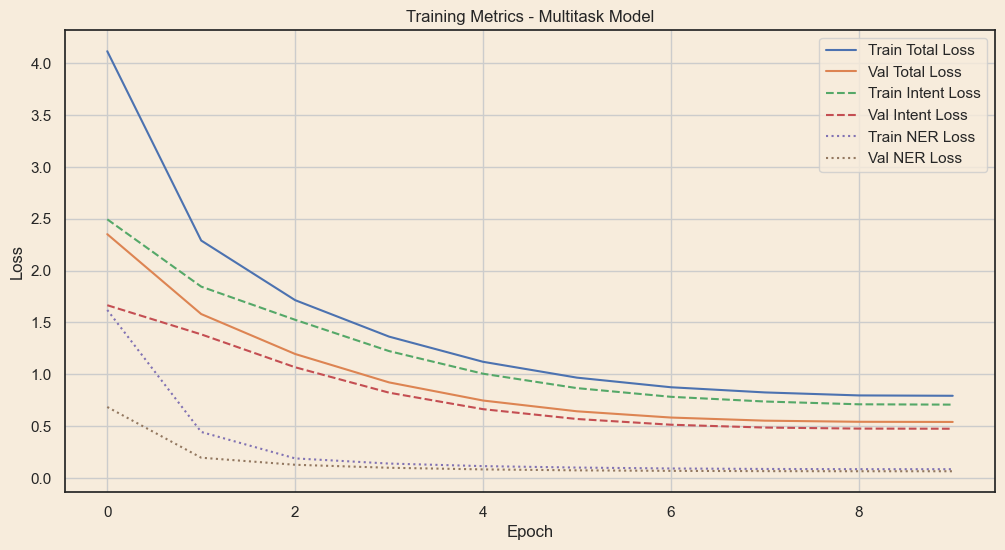

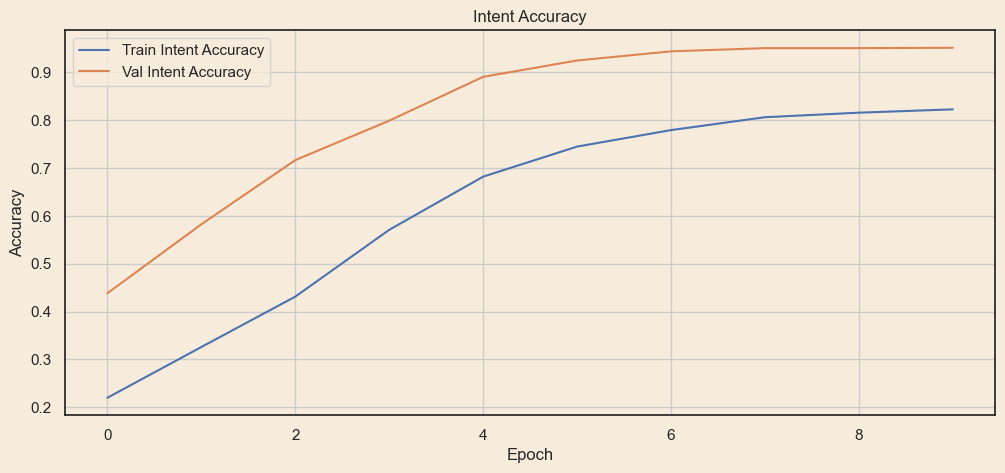

In [58]:
plot_multitask_history(history)

## Results and Analysis


### Evaluation Metrics
Intent evaluation reports accuracy, precision, recall, and F1 (macro and weighted) to capture both global and class-balanced performance.

NER evaluation is token-level and excludes masked positions. Because label `O` is dominant, macro-F1 and confusion patterns are emphasized to avoid inflated interpretations from weighted averages alone.


In [59]:
df_intent_report, y_true, y_pred = evaluar_intent_df(
    model,
    test_ds,
    id2intent
)


=== Classification Report (Intent) ===
                            precision  recall  f1-score    support
acceso_canales_digitales       1.0000  0.6835    0.8120    79.0000
acreditacion_pago              1.0000  0.7000    0.8235    70.0000
acreditacion_transferencia     1.0000  0.9500    0.9744   100.0000
controversia_compra            0.9213  1.0000    0.9590   281.0000
cuenta_otros                   0.9013  0.9580    0.9288   143.0000
fraude_desconocimiento         1.0000  0.9722    0.9859   144.0000
rechazo_prevencion_fraude      0.9358  1.0000    0.9669   350.0000
token_2fa                      1.0000  0.9394    0.9688    33.0000
accuracy                       0.9475  0.9475    0.9475     0.9475
macro avg                      0.9698  0.9004    0.9274  1200.0000
weighted avg                   0.9511  0.9475    0.9449  1200.0000


Intent classification performance is strong overall, with high weighted and macro F1. Errors are concentrated in lower-support classes, which is consistent with residual class imbalance.

Interpretation: the shared encoder captures intent-level semantics effectively, and the pipeline is reliable for primary triage use cases.


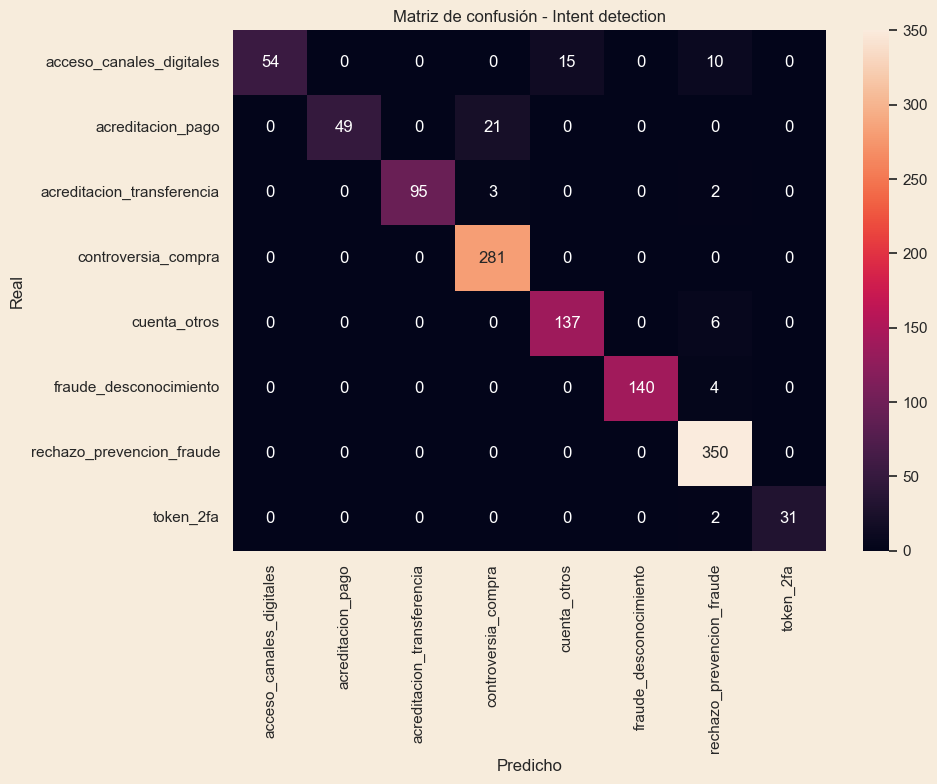

In [60]:
cm, labels = matriz_confusion_intent(
    y_true,
    y_pred
)

In [61]:
df_ne_report = evaluar_ner_df(
    model,
    test_ds,
    id2label,
    cfg
)


=== NER Classification Report ===
              precision    recall  f1-score   support

    B-AMOUNT       0.53      0.77      0.63       617
   B-CHANNEL       0.00      0.00      0.00        81
   B-COUNTRY       0.00      0.00      0.00       100
  B-CURRENCY       0.48      0.79      0.59       634
  B-MERCHANT       0.15      0.03      0.05       577
   B-PRODUCT       0.00      0.00      0.00       277
    I-AMOUNT       0.61      0.80      0.69       650
   I-CHANNEL       0.00      0.00      0.00        81
   I-COUNTRY       0.00      0.00      0.00        18
  I-CURRENCY       0.86      0.79      0.82       485
  I-MERCHANT       0.53      0.32      0.40       832
           O       0.99      0.99      0.99    302848

    accuracy                           0.99    307200
   macro avg       0.35      0.37      0.35    307200
weighted avg       0.99      0.99      0.99    307200


=== Confusion Distribution ===
          true        pred   count
0     B-AMOUNT    B-AMOUNT     

NER performance is high on frequent entity types but uneven on rare labels. The gap between weighted and macro metrics indicates dominance of non-entity tokens (`O`) and reduced recall on minority entities.

Interpretation: extraction quality is production-promising for common fields, but long-tail entities require additional balancing strategies.


In [62]:
mostrar_ejemplos_random(
    model,
    test_ds,
    id2intent,
    cfg,
    n=3
)


===== EJEMPLOS RANDOM =====

Texto:

[ CUSTOMER ] Buenas tardes. Soy Agustín. Hice una transferencia y no se acredita. [ CUSTOMER ] La hice por la app por
89. 00 EUR y al destinatario no le llegó. [ CUSTOMER ] Muchas gracias.

Intent real: acreditacion_transferencia
Intent pred: acreditacion_transferencia

Texto:

[ CUSTOMER ] Buen día. Soy Germán. Estoy intentando pagar y me rechaza la tarjeta de crédito. [ CUSTOMER ] Me figura
autorización rechazada. [ CUSTOMER ] Gracias.

Intent real: rechazo_prevencion_fraude
Intent pred: rechazo_prevencion_fraude

Texto:

[ CUSTOMER ] Buenas tardes. Soy Carolina. Quiero disputar una compra con mi tarjeta de crédito. [ CUSTOMER ] Me cobraron
59, 99 USD en Meta pero el servicio no se prestó o llegó mal. [ AGENT ] Operador / a : Para controversias necesitamos
fecha, comprobante y evidencia del reclamo al comercio. [ CUSTOMER ] Carolina : Tengo capturas y comprobante. ¿ Dónde lo
adjunto? [ AGENT ] Te indico el ...

Intent real: controversia_compra
In

## Key Insights
1. Joint intent+NER learning with a shared Transformer is effective for this domain.
2. Freezing the encoder provided stable optimization under synthetic-data conditions.
3. Intent detection is robust; NER remains sensitive to entity imbalance.

## Conclusion
The project demonstrates a credible multi-task NLP baseline for banking-claim automation. The architecture is reproducible, technically sound, and suitable for portfolio-level presentation, with clear paths for improving long-tail NER behavior.


## Recommended Next Improvements
1. Introduce stronger class-balancing strategies for minority intents and entities.
2. Evaluate focal or cost-sensitive losses for token-level NER.
3. Add entity-level metrics and BIO-consistency post-processing.
4. Validate on real or hybrid data to measure out-of-distribution robustness.
